# SegAnyMo vs GenMatter vs FlowSAM Accuracy Analysis

Visualizes performance comparison between SegAnyMo, GenMatter (HDGMM), and FlowSAM across scenes and textures.

**Data Source**: `/home/esli/GenMatter/analysis_results/all_results.json`

All methods are evaluated at 96×96 resolution for fair comparison.

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from collections import defaultdict
from scipy import stats

# Paths
DATA_DIR = Path('/home/esli/GenMatter/analysis_results')
OUTPUT_DIR = DATA_DIR / 'plots'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load unified results file
with open(DATA_DIR / 'all_results.json', 'r') as f:
    all_results = json.load(f)

# Load per-scene and per-texture breakdowns
with open(DATA_DIR / 'breakdown_by_scene.json', 'r') as f:
    per_scene = json.load(f)
with open(DATA_DIR / 'breakdown_by_texture.json', 'r') as f:
    per_texture = json.load(f)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
colors = {'seganymo': '#E63946', 'hdgmm': '#457B9D', 'flowsam': '#2A9D8F'}

print(f"Data loaded: {len(all_results)} scene-texture pairs")
print(f"Per-scene breakdown: {len(per_scene)} scenes")
print(f"Per-texture breakdown: {len(per_texture)} textures")

# Count valid results per method
seganymo_count = sum(1 for r in all_results if r.get('seganymo_mean') is not None)
flowsam_count = sum(1 for r in all_results if r.get('flowsam_mean') is not None)
hdgmm_count = sum(1 for r in all_results if r.get('hdgmm_mean') is not None)
print(f"\nValid results: SegAnyMo={seganymo_count}, FlowSAM={flowsam_count}, GenMatter={hdgmm_count}")

Data loaded: 140 scene-texture pairs
Per-scene breakdown: 20 scenes
Per-texture breakdown: 7 textures

Valid results: SegAnyMo=140, FlowSAM=140, GenMatter=140


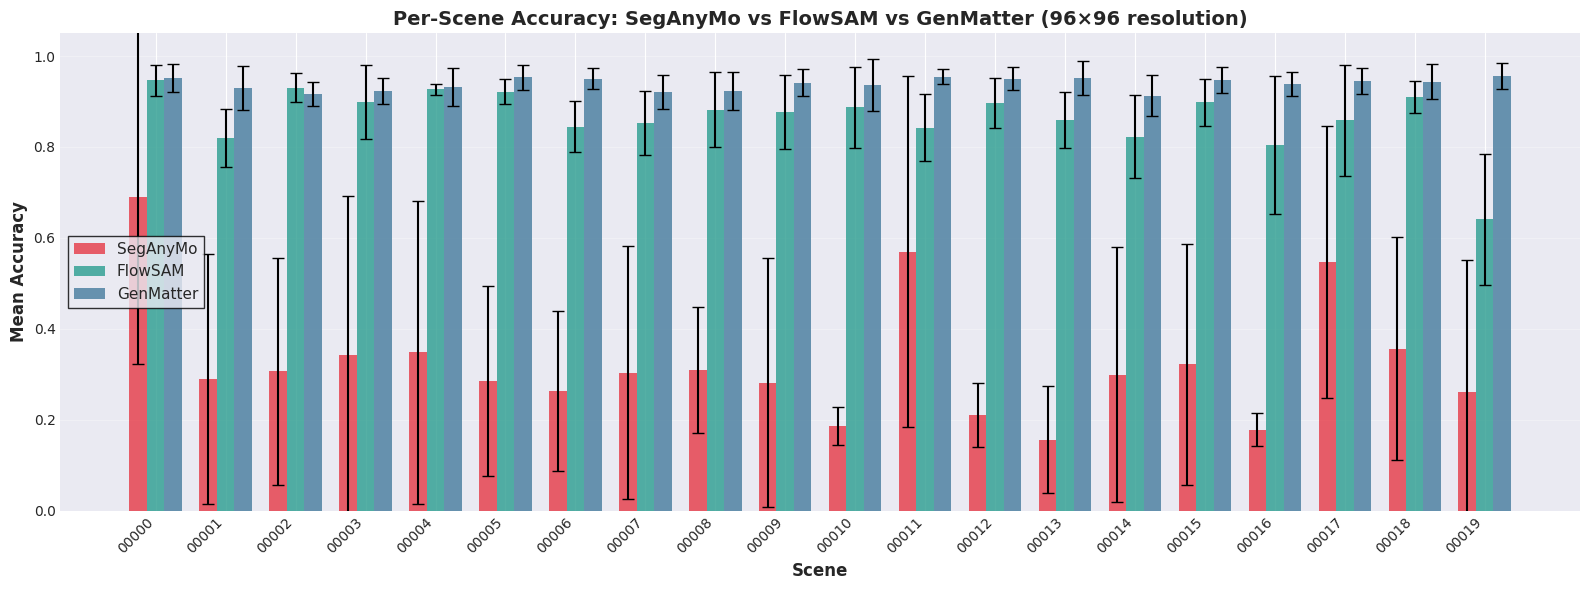

Saved: /home/esli/GenMatter/analysis_results/plots/per_scene_comparison.png


In [2]:
# Per-Scene Comparison

fig, ax = plt.subplots(figsize=(16, 6))

scenes = [item['scene'] for item in per_scene]
x_pos = np.arange(len(scenes))

seganymo_means = [item['seganymo_mean'] for item in per_scene]
flowsam_means = [item['flowsam_mean'] for item in per_scene]
hdgmm_means = [item['hdgmm_mean'] for item in per_scene]

# Compute standard deviations from individual results
seganymo_stds = []
flowsam_stds = []
hdgmm_stds = []

for scene in scenes:
    scene_data = [r for r in all_results if r['scene'] == scene]
    seganymo_stds.append(np.std([r['seganymo_mean'] for r in scene_data if r['seganymo_mean'] is not None]))
    flowsam_stds.append(np.std([r['flowsam_mean'] for r in scene_data if r['flowsam_mean'] is not None]))
    hdgmm_stds.append(np.std([r['hdgmm_mean'] for r in scene_data if r['hdgmm_mean'] is not None]))

width = 0.25
ax.bar(x_pos - width, seganymo_means, width, yerr=seganymo_stds, 
       label='SegAnyMo', color=colors['seganymo'], alpha=0.8, 
       capsize=4, error_kw={'linewidth': 1.5})
ax.bar(x_pos, flowsam_means, width, yerr=flowsam_stds,
       label='FlowSAM', color=colors['flowsam'], alpha=0.8,
       capsize=4, error_kw={'linewidth': 1.5})
ax.bar(x_pos + width, hdgmm_means, width, yerr=hdgmm_stds,
       label='GenMatter', color=colors['hdgmm'], alpha=0.8,
       capsize=4, error_kw={'linewidth': 1.5})

ax.set_xlabel('Scene', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Per-Scene Accuracy: SegAnyMo vs FlowSAM vs GenMatter (96×96 resolution)', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([s.replace('scene_', '') for s in scenes], rotation=45, ha='right')
ax.legend(fontsize=11, frameon=True, edgecolor='black', fancybox=False)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'per_scene_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'per_scene_comparison.pdf', bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'per_scene_comparison.png'}")

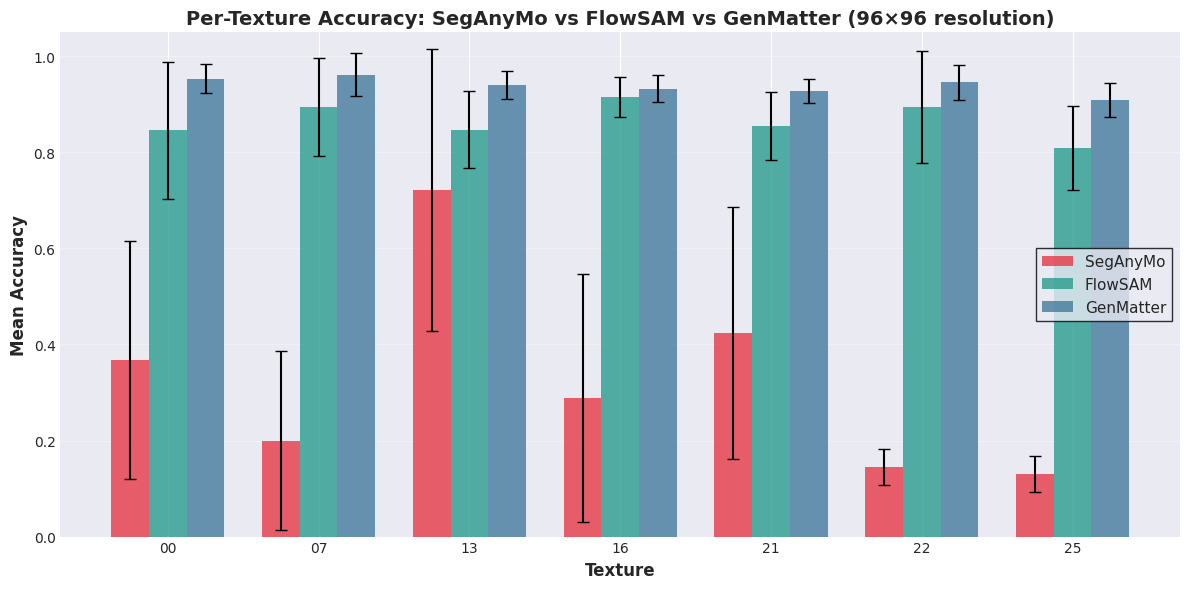

Saved: /home/esli/GenMatter/analysis_results/plots/per_texture_comparison.png


In [3]:
# Per-Texture Comparison

fig, ax = plt.subplots(figsize=(12, 6))

textures = [item['texture'] for item in per_texture]
x_pos = np.arange(len(textures))

seganymo_means = [item['seganymo_mean'] for item in per_texture]
flowsam_means = [item['flowsam_mean'] for item in per_texture]
hdgmm_means = [item['hdgmm_mean'] for item in per_texture]

# Compute standard deviations from individual results
seganymo_stds = []
flowsam_stds = []
hdgmm_stds = []

for texture in textures:
    texture_data = [r for r in all_results if r['texture'] == texture]
    seganymo_stds.append(np.std([r['seganymo_mean'] for r in texture_data if r['seganymo_mean'] is not None]))
    flowsam_stds.append(np.std([r['flowsam_mean'] for r in texture_data if r['flowsam_mean'] is not None]))
    hdgmm_stds.append(np.std([r['hdgmm_mean'] for r in texture_data if r['hdgmm_mean'] is not None]))

width = 0.25
ax.bar(x_pos - width, seganymo_means, width, yerr=seganymo_stds,
       label='SegAnyMo', color=colors['seganymo'], alpha=0.8,
       capsize=4, error_kw={'linewidth': 1.5})
ax.bar(x_pos, flowsam_means, width, yerr=flowsam_stds,
       label='FlowSAM', color=colors['flowsam'], alpha=0.8,
       capsize=4, error_kw={'linewidth': 1.5})
ax.bar(x_pos + width, hdgmm_means, width, yerr=hdgmm_stds,
       label='GenMatter', color=colors['hdgmm'], alpha=0.8,
       capsize=4, error_kw={'linewidth': 1.5})

ax.set_xlabel('Texture', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Per-Texture Accuracy: SegAnyMo vs FlowSAM vs GenMatter (96×96 resolution)', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([t.replace('texture_', '') for t in textures], rotation=0)
ax.legend(fontsize=11, frameon=True, edgecolor='black', fancybox=False)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'per_texture_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'per_texture_comparison.pdf', bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'per_texture_comparison.png'}")

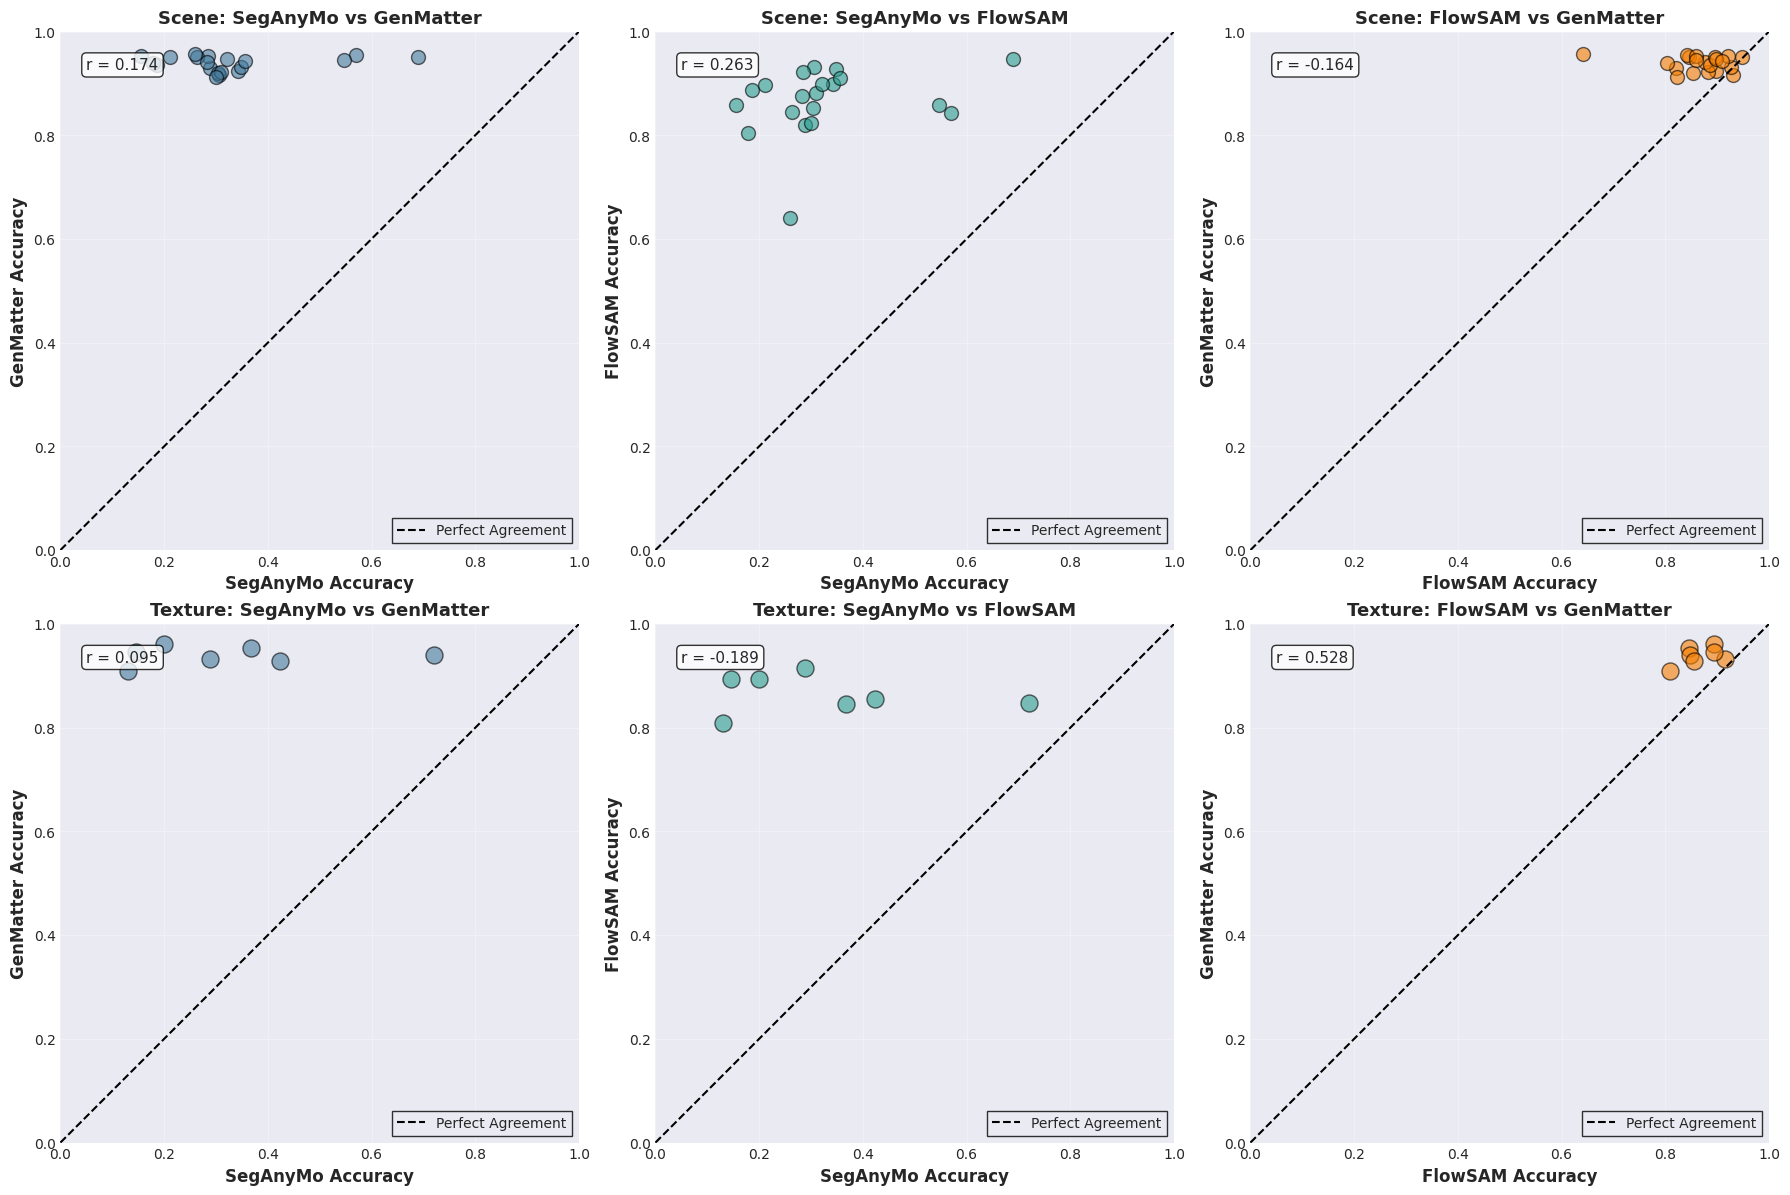

Saved: /home/esli/GenMatter/analysis_results/plots/scatter_comparison.png


In [4]:
# Scatter Plot: Pairwise Correlations

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Scene-level data
seganymo_scene = [item['seganymo_mean'] for item in per_scene]
flowsam_scene = [item['flowsam_mean'] for item in per_scene]
hdgmm_scene = [item['hdgmm_mean'] for item in per_scene]

# Texture-level data
seganymo_texture = [item['seganymo_mean'] for item in per_texture]
flowsam_texture = [item['flowsam_mean'] for item in per_texture]
hdgmm_texture = [item['hdgmm_mean'] for item in per_texture]

# Scene scatter: SegAnyMo vs GenMatter
ax1 = axes[0, 0]
ax1.scatter(seganymo_scene, hdgmm_scene, s=100, alpha=0.6, color=colors['hdgmm'], edgecolors='black')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfect Agreement')
ax1.set_xlabel('SegAnyMo Accuracy', fontsize=12, fontweight='bold')
ax1.set_ylabel('GenMatter Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Scene: SegAnyMo vs GenMatter', fontsize=13, fontweight='bold')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.legend(frameon=True, edgecolor='black', fancybox=False)
ax1.grid(alpha=0.3)
ax1.set_aspect('equal')
corr = np.corrcoef(seganymo_scene, hdgmm_scene)[0, 1]
ax1.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax1.transAxes,
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Scene scatter: SegAnyMo vs FlowSAM
ax2 = axes[0, 1]
ax2.scatter(seganymo_scene, flowsam_scene, s=100, alpha=0.6, color=colors['flowsam'], edgecolors='black')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfect Agreement')
ax2.set_xlabel('SegAnyMo Accuracy', fontsize=12, fontweight='bold')
ax2.set_ylabel('FlowSAM Accuracy', fontsize=12, fontweight='bold')
ax2.set_title('Scene: SegAnyMo vs FlowSAM', fontsize=13, fontweight='bold')
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.legend(frameon=True, edgecolor='black', fancybox=False)
ax2.grid(alpha=0.3)
ax2.set_aspect('equal')
corr = np.corrcoef(seganymo_scene, flowsam_scene)[0, 1]
ax2.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax2.transAxes,
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Scene scatter: FlowSAM vs GenMatter
ax3 = axes[0, 2]
ax3.scatter(flowsam_scene, hdgmm_scene, s=100, alpha=0.6, color='#F77F00', edgecolors='black')
ax3.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfect Agreement')
ax3.set_xlabel('FlowSAM Accuracy', fontsize=12, fontweight='bold')
ax3.set_ylabel('GenMatter Accuracy', fontsize=12, fontweight='bold')
ax3.set_title('Scene: FlowSAM vs GenMatter', fontsize=13, fontweight='bold')
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
ax3.legend(frameon=True, edgecolor='black', fancybox=False)
ax3.grid(alpha=0.3)
ax3.set_aspect('equal')
corr = np.corrcoef(flowsam_scene, hdgmm_scene)[0, 1]
ax3.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax3.transAxes,
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Texture scatter: SegAnyMo vs GenMatter
ax4 = axes[1, 0]
ax4.scatter(seganymo_texture, hdgmm_texture, s=150, alpha=0.6, color=colors['hdgmm'], edgecolors='black')
ax4.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfect Agreement')
ax4.set_xlabel('SegAnyMo Accuracy', fontsize=12, fontweight='bold')
ax4.set_ylabel('GenMatter Accuracy', fontsize=12, fontweight='bold')
ax4.set_title('Texture: SegAnyMo vs GenMatter', fontsize=13, fontweight='bold')
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)
ax4.legend(frameon=True, edgecolor='black', fancybox=False)
ax4.grid(alpha=0.3)
ax4.set_aspect('equal')
corr = np.corrcoef(seganymo_texture, hdgmm_texture)[0, 1]
ax4.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax4.transAxes,
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Texture scatter: SegAnyMo vs FlowSAM
ax5 = axes[1, 1]
ax5.scatter(seganymo_texture, flowsam_texture, s=150, alpha=0.6, color=colors['flowsam'], edgecolors='black')
ax5.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfect Agreement')
ax5.set_xlabel('SegAnyMo Accuracy', fontsize=12, fontweight='bold')
ax5.set_ylabel('FlowSAM Accuracy', fontsize=12, fontweight='bold')
ax5.set_title('Texture: SegAnyMo vs FlowSAM', fontsize=13, fontweight='bold')
ax5.set_xlim(0, 1)
ax5.set_ylim(0, 1)
ax5.legend(frameon=True, edgecolor='black', fancybox=False)
ax5.grid(alpha=0.3)
ax5.set_aspect('equal')
corr = np.corrcoef(seganymo_texture, flowsam_texture)[0, 1]
ax5.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax5.transAxes,
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Texture scatter: FlowSAM vs GenMatter
ax6 = axes[1, 2]
ax6.scatter(flowsam_texture, hdgmm_texture, s=150, alpha=0.6, color='#F77F00', edgecolors='black')
ax6.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfect Agreement')
ax6.set_xlabel('FlowSAM Accuracy', fontsize=12, fontweight='bold')
ax6.set_ylabel('GenMatter Accuracy', fontsize=12, fontweight='bold')
ax6.set_title('Texture: FlowSAM vs GenMatter', fontsize=13, fontweight='bold')
ax6.set_xlim(0, 1)
ax6.set_ylim(0, 1)
ax6.legend(frameon=True, edgecolor='black', fancybox=False)
ax6.grid(alpha=0.3)
ax6.set_aspect('equal')
corr = np.corrcoef(flowsam_texture, hdgmm_texture)[0, 1]
ax6.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax6.transAxes,
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scatter_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'scatter_comparison.pdf', bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'scatter_comparison.png'}")

In [5]:
# Statistical Summary

print("="*80)
print("STATISTICAL SUMMARY - ACCURACY")
print("="*80)

# Overall statistics from all_results
seganymo_all = [r['seganymo_mean'] for r in all_results if r['seganymo_mean'] is not None]
flowsam_all = [r['flowsam_mean'] for r in all_results if r['flowsam_mean'] is not None]
hdgmm_all = [r['hdgmm_mean'] for r in all_results if r['hdgmm_mean'] is not None]

print(f"\nOverall (N={len(all_results)} scene-texture pairs):")
print(f"  SegAnyMo: {np.mean(seganymo_all):.4f} ± {np.std(seganymo_all):.4f} (range: [{np.min(seganymo_all):.4f}, {np.max(seganymo_all):.4f}])")
print(f"  FlowSAM:  {np.mean(flowsam_all):.4f} ± {np.std(flowsam_all):.4f} (range: [{np.min(flowsam_all):.4f}, {np.max(flowsam_all):.4f}])")
print(f"  HDGMM:    {np.mean(hdgmm_all):.4f} ± {np.std(hdgmm_all):.4f} (range: [{np.min(hdgmm_all):.4f}, {np.max(hdgmm_all):.4f}])")

# Per-scene statistics
print(f"\nPer-Scene (N={len(per_scene)} scenes):")
seganymo_scene = [item['seganymo_mean'] for item in per_scene]
flowsam_scene = [item['flowsam_mean'] for item in per_scene]
hdgmm_scene = [item['hdgmm_mean'] for item in per_scene]
print(f"  SegAnyMo: {np.mean(seganymo_scene):.4f} ± {np.std(seganymo_scene):.4f}")
print(f"  FlowSAM:  {np.mean(flowsam_scene):.4f} ± {np.std(flowsam_scene):.4f}")
print(f"  HDGMM:    {np.mean(hdgmm_scene):.4f} ± {np.std(hdgmm_scene):.4f}")
print(f"  Correlation (SegAnyMo vs GenMatter): r = {np.corrcoef(seganymo_scene, hdgmm_scene)[0,1]:.3f}")
print(f"  Correlation (SegAnyMo vs FlowSAM): r = {np.corrcoef(seganymo_scene, flowsam_scene)[0,1]:.3f}")
print(f"  Correlation (FlowSAM vs GenMatter): r = {np.corrcoef(flowsam_scene, hdgmm_scene)[0,1]:.3f}")

# Per-texture statistics
print(f"\nPer-Texture (N={len(per_texture)} textures):")
seganymo_texture = [item['seganymo_mean'] for item in per_texture]
flowsam_texture = [item['flowsam_mean'] for item in per_texture]
hdgmm_texture = [item['hdgmm_mean'] for item in per_texture]
print(f"  SegAnyMo: {np.mean(seganymo_texture):.4f} ± {np.std(seganymo_texture):.4f}")
print(f"  FlowSAM:  {np.mean(flowsam_texture):.4f} ± {np.std(flowsam_texture):.4f}")
print(f"  HDGMM:    {np.mean(hdgmm_texture):.4f} ± {np.std(hdgmm_texture):.4f}")
print(f"  Correlation (SegAnyMo vs GenMatter): r = {np.corrcoef(seganymo_texture, hdgmm_texture)[0,1]:.3f}")
print(f"  Correlation (SegAnyMo vs FlowSAM): r = {np.corrcoef(seganymo_texture, flowsam_texture)[0,1]:.3f}")
print(f"  Correlation (FlowSAM vs GenMatter): r = {np.corrcoef(flowsam_texture, hdgmm_texture)[0,1]:.3f}")

# Paired t-tests
print("\n" + "="*80)
print("PAIRED T-TESTS")
print("="*80)

t_stat_sh, p_value_sh = stats.ttest_rel(seganymo_all, hdgmm_all)
print(f"\nSegAnyMo vs GenMatter:")
print(f"  Mean difference: {np.mean(np.array(seganymo_all) - np.array(hdgmm_all)):.4f}")
print(f"  t-test: t={t_stat_sh:.4f}, p={p_value_sh:.6f}")
print(f"  SegAnyMo wins: {sum(s > h for s, h in zip(seganymo_all, hdgmm_all))}/{len(seganymo_all)}")

t_stat_sf, p_value_sf = stats.ttest_rel(seganymo_all, flowsam_all)
print(f"\nSegAnyMo vs FlowSAM:")
print(f"  Mean difference: {np.mean(np.array(seganymo_all) - np.array(flowsam_all)):.4f}")
print(f"  t-test: t={t_stat_sf:.4f}, p={p_value_sf:.6f}")
print(f"  SegAnyMo wins: {sum(s > f for s, f in zip(seganymo_all, flowsam_all))}/{len(seganymo_all)}")

t_stat_fh, p_value_fh = stats.ttest_rel(flowsam_all, hdgmm_all)
print(f"\nFlowSAM vs GenMatter:")
print(f"  Mean difference: {np.mean(np.array(flowsam_all) - np.array(hdgmm_all)):.4f}")
print(f"  t-test: t={t_stat_fh:.4f}, p={p_value_fh:.6f}")
print(f"  FlowSAM wins: {sum(f > h for f, h in zip(flowsam_all, hdgmm_all))}/{len(flowsam_all)}")

print("\n" + "="*80)
print(f"All plots saved to: {OUTPUT_DIR}")
print("="*80)

STATISTICAL SUMMARY - ACCURACY

Overall (N=140 scene-texture pairs):
  SegAnyMo: 0.3252 ± 0.2869 (range: [0.0638, 0.9700])
  FlowSAM:  0.8660 ± 0.1024 (range: [0.4268, 0.9878])
  HDGMM:    0.9388 ± 0.0372 (range: [0.8020, 0.9906])

Per-Scene (N=20 scenes):
  SegAnyMo: 0.3252 ± 0.1305
  FlowSAM:  0.8660 ± 0.0644
  HDGMM:    0.9388 ± 0.0135
  Correlation (SegAnyMo vs GenMatter): r = 0.174
  Correlation (SegAnyMo vs FlowSAM): r = 0.263
  Correlation (FlowSAM vs GenMatter): r = -0.164

Per-Texture (N=7 textures):
  SegAnyMo: 0.3252 ± 0.1912
  FlowSAM:  0.8660 ± 0.0342
  HDGMM:    0.9388 ± 0.0161
  Correlation (SegAnyMo vs GenMatter): r = 0.095
  Correlation (SegAnyMo vs FlowSAM): r = -0.189
  Correlation (FlowSAM vs GenMatter): r = 0.528

PAIRED T-TESTS

SegAnyMo vs GenMatter:
  Mean difference: -0.6137
  t-test: t=-25.2724, p=0.000000
  SegAnyMo wins: 7/140

SegAnyMo vs FlowSAM:
  Mean difference: -0.5408
  t-test: t=-20.8829, p=0.000000
  SegAnyMo wins: 12/140

FlowSAM vs GenMatter:
  Me